# E5 WOM Compensation Analysis
Comprehensive notebook for publication-quality analysis.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"]=(8,5)
plt.rcParams["font.family"]="DejaVu Sans"

df=pd.read_csv("./experiments/e5-2/table.csv", skiprows=6)
df.head()


,[run number],number-of-shoppers,reward-cycles,reward-duration,withdrawal-duration,low-reward-salience,high-reward-salience,wom-on?,network-topology,network-degree,...,high-reward-withdrawal-drop,high-reward-retention-ratio,"persistence-index ""high-salience""","mean-intrinsic-motivation ""high-salience""","mean-habit ""high-salience""","mean-opinion ""high-salience""",wom-speaker-share,wom-receiver-share,mean-absolute-wom-opinion-change,mean-network-degree
0,9,1200,1,60,80,0.15,0.75,False,small-world,4,...,0.413052,0.516380,0.037198,0.417444,0.400375,0.068183,0.0,0.0,0.0,4.0
1,1,1200,1,60,80,0.15,0.75,False,small-world,4,...,0.403219,0.525485,0.060281,0.414989,0.412875,0.076255,0.0,0.0,0.0,4.0
2,5,1200,1,60,80,0.15,0.75,False,small-world,4,...,0.399750,0.525238,0.042917,0.415103,0.404625,0.071668,0.0,0.0,0.0,4.0
3,4,1200,1,60,80,0.15,0.75,False,small-world,4,...,0.411781,0.505887,0.050010,0.413756,0.382625,0.066650,0.0,0.0,0.0,4.0
4,2,1200,1,60,80,0.15,0.75,False,small-world,4,...,0.399958,0.525178,0.051958,0.421448,0.397000,0.070580,0.0,0.0,0.0,4.0


In [28]:
df.shape

(3240, 28)

In [29]:
df.columns.tolist()

['[run number]',
 'number-of-shoppers',
 'reward-cycles',
 'reward-duration',
 'withdrawal-duration',
 'low-reward-salience',
 'high-reward-salience',
 'wom-on?',
 'network-topology',
 'network-degree',
 'rewiring-probability',
 'purchase-deliberation-mode',
 'confidence-bound',
 'show-network?',
 '[step]',
 'choice-rate "high-salience" "baseline"',
 'choice-rate "high-salience" "reward"',
 'final-withdrawal-choice-rate "high-salience"',
 'high-reward-withdrawal-drop',
 'high-reward-retention-ratio',
 'persistence-index "high-salience"',
 'mean-intrinsic-motivation "high-salience"',
 'mean-habit "high-salience"',
 'mean-opinion "high-salience"',
 'wom-speaker-share',
 'wom-receiver-share',
 'mean-absolute-wom-opinion-change',
 'mean-network-degree']

## Clean data

In [30]:
df=df.dropna(axis=1,how="all")
df.columns=[c.strip() for c in df.columns]
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
[run number],3240.0,NaN,NaN,NaN,1620.5,935.451763,1.0,810.75,1620.5,2430.25,3240.0
number-of-shoppers,3240.0,NaN,NaN,NaN,1200.0,0.0,1200.0,1200.0,1200.0,1200.0,1200.0
reward-cycles,3240.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
reward-duration,3240.0,NaN,NaN,NaN,60.0,0.0,60.0,60.0,60.0,60.0,60.0
withdrawal-duration,3240.0,NaN,NaN,NaN,80.0,0.0,80.0,80.0,80.0,80.0,80.0
low-reward-salience,3240.0,NaN,NaN,NaN,0.15,0.0,0.15,0.15,0.15,0.15,0.15
high-reward-salience,3240.0,NaN,NaN,NaN,0.75,0.0,0.75,0.75,0.75,0.75,0.75
wom-on?,3240,2,False,1620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
network-topology,3240,3,small-world,1080,NaN,NaN,NaN,NaN,NaN,NaN,NaN
network-degree,3240.0,NaN,NaN,NaN,8.0,3.26649,4.0,4.0,8.0,12.0,12.0


## Configuration

In [31]:
TARGET = 'final-withdrawal-choice-rate "high-salience"'
FACTORS=[
    "wom-on?",
    "network-topology",
    "network-degree",
    "purchase-deliberation-mode",
    "confidence-bound",
    "opinion-weight"
]
FACTORS=[c for c in FACTORS if c in df.columns]
FACTORS


['wom-on?',
 'network-topology',
 'network-degree',
 'purchase-deliberation-mode',
 'confidence-bound']

## Aggregate

In [32]:
summary=df.groupby(FACTORS)[TARGET].agg(["mean","std","count"]).reset_index()
display(summary.sort_values("mean",ascending=False).head(20))


,wom-on?,network-topology,network-degree,purchase-deliberation-mode,confidence-bound,mean,std,count
102,True,small-world,12,high-involvement,0.3,0.445924,0.008117,30
103,True,small-world,12,high-involvement,0.6,0.444956,0.008765,30
67,True,preferential-attachment,12,high-involvement,0.6,0.443664,0.007630,30
86,True,random,12,high-involvement,1.0,0.443131,0.005906,30
55,True,preferential-attachment,4,high-involvement,0.6,0.442751,0.006624,30
100,True,small-world,8,low-involvement,0.6,0.442705,0.007692,30
79,True,random,8,high-involvement,0.6,0.442669,0.006483,30
96,True,small-world,8,high-involvement,0.3,0.442167,0.009773,30
68,True,preferential-attachment,12,high-involvement,1.0,0.442144,0.007244,30
3,False,preferential-attachment,4,low-involvement,0.3,0.441961,0.006590,30


## Compensation of WOM

In [33]:
if "wom-on?" in FACTORS:
    join=[c for c in FACTORS if c!="wom-on?"]
    wom=summary[summary["wom-on?"]==True]
    base=summary[summary["wom-on?"]==False]
    merged=wom.merge(base[join+["mean"]],on=join,suffixes=("_wom","_base"))
    merged["compensation"]=merged["mean_wom"]-merged["mean_base"]
    display(merged.sort_values("compensation",ascending=False).head(20))
else:
    merged=summary.copy()


,wom-on?,network-topology,network-degree,purchase-deliberation-mode,confidence-bound,mean_wom,std,count,mean_base,compensation
49,True,small-world,12,high-involvement,0.6,0.444956,0.008765,30,0.438010,0.006946
48,True,small-world,12,high-involvement,0.3,0.445924,0.008117,30,0.439595,0.006329
0,True,preferential-attachment,4,high-involvement,0.3,0.441835,0.008603,30,0.436592,0.005244
46,True,small-world,8,low-involvement,0.6,0.442705,0.007692,30,0.437669,0.005036
13,True,preferential-attachment,12,high-involvement,0.6,0.443664,0.007630,30,0.438733,0.004930
6,True,preferential-attachment,8,high-involvement,0.3,0.440322,0.008334,30,0.435653,0.004669
32,True,random,12,high-involvement,1.0,0.443131,0.005906,30,0.438530,0.004601
18,True,random,4,high-involvement,0.3,0.441049,0.007125,30,0.436924,0.004125
24,True,random,8,high-involvement,0.3,0.440772,0.006773,30,0.436919,0.003853
14,True,preferential-attachment,12,high-involvement,1.0,0.442144,0.007244,30,0.438432,0.003711


## Heatmaps

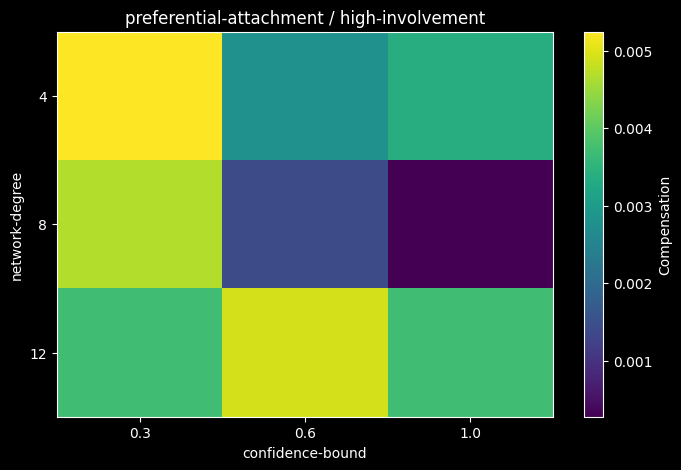

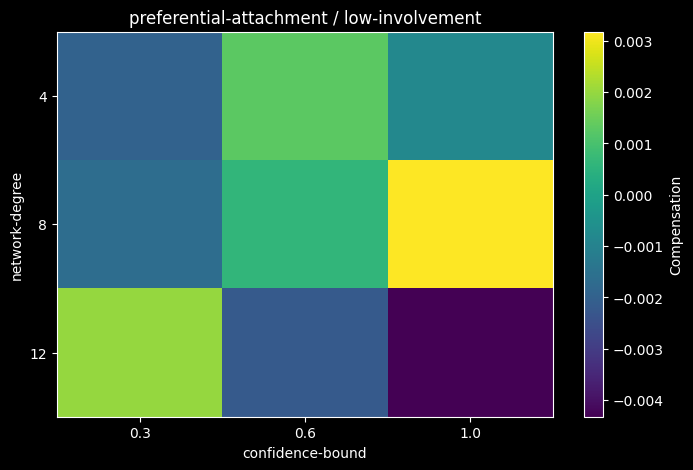

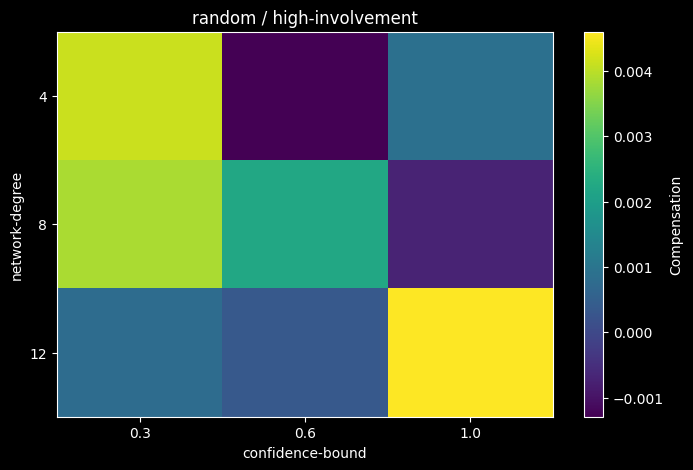

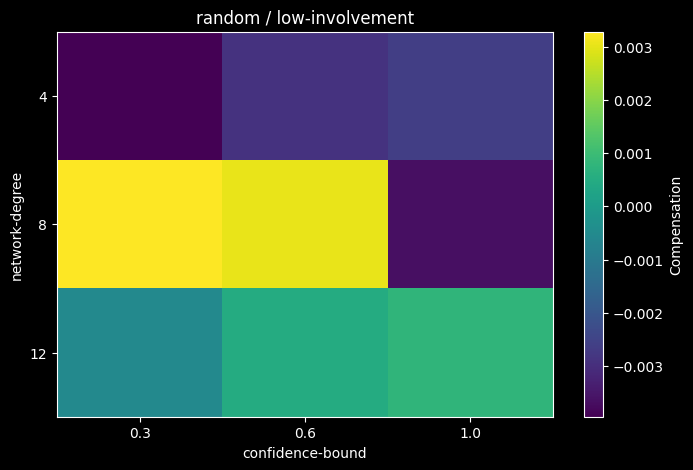

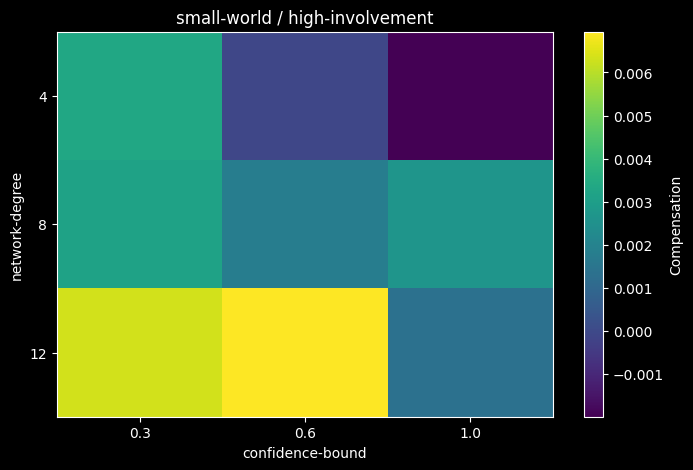

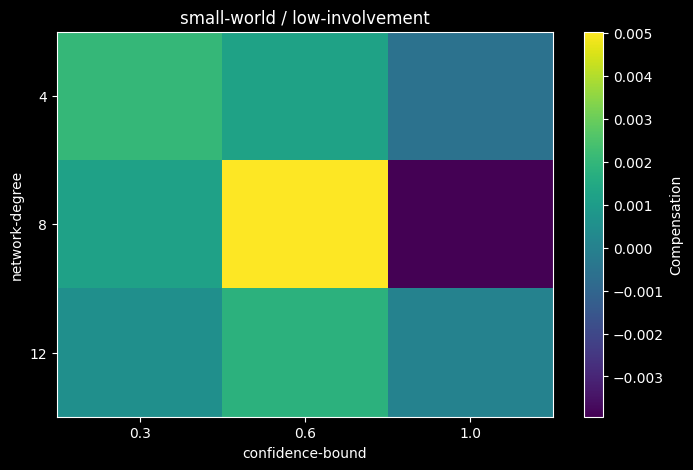

In [34]:
if len(merged):
    tops=merged["network-topology"].unique() if "network-topology" in merged else []
    modes=merged["purchase-deliberation-mode"].unique() if "purchase-deliberation-mode" in merged else []
    for topo in tops:
        for mode in modes:
            d=merged[(merged["network-topology"]==topo)&(merged["purchase-deliberation-mode"]==mode)]
            if d.empty: continue
            pv=d.pivot(index="network-degree",columns="confidence-bound",values="compensation")
            plt.figure()
            plt.imshow(pv.values,aspect="auto")
            plt.xticks(range(len(pv.columns)),pv.columns)
            plt.yticks(range(len(pv.index)),pv.index)
            plt.xlabel("confidence-bound")
            plt.ylabel("network-degree")
            plt.title(f"{topo} / {mode}")
            plt.colorbar(label="Compensation")
            plt.show()


## Opinion weight analysis

In [35]:
if "opinion-weight" in merged.columns:
    plt.figure()
    g=merged.groupby("opinion-weight")["compensation"].mean()
    plt.plot(g.index,g.values,marker="o")
    plt.xlabel("Opinion weight")
    plt.ylabel("Mean compensation")
    plt.grid(True)
    plt.show()


## Interaction plots

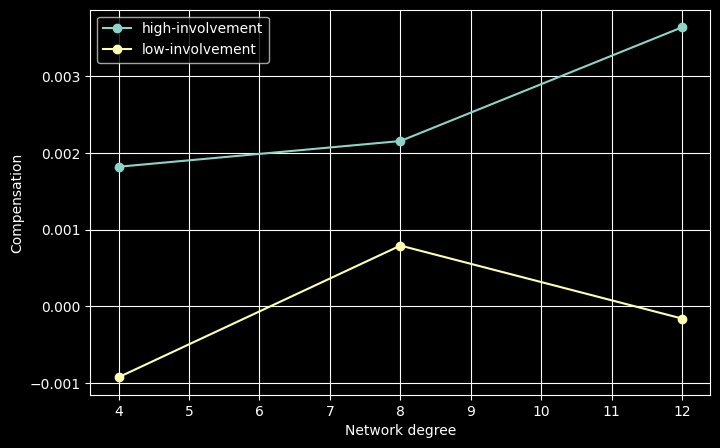

In [36]:
if "purchase-deliberation-mode" in merged.columns:
    plt.figure()
    for mode,g in merged.groupby("purchase-deliberation-mode"):
        x=g.groupby("network-degree")["compensation"].mean()
        plt.plot(x.index,x.values,marker="o",label=mode)
    plt.legend()
    plt.xlabel("Network degree")
    plt.ylabel("Compensation")
    plt.grid(True)
    plt.show()


## Factor importance (variance explained proxy)

In [37]:
for c in FACTORS:
    if c=="wom-on?": continue
    if c not in merged: continue
    vals=merged.groupby(c)["compensation"].mean().sort_values(ascending=False)
    print("\n",c)
    display(vals)



 network-topology


network-topology
small-world                0.001717
preferential-attachment    0.001457
random                     0.000486
Name: compensation, dtype: float64


 network-degree


network-degree
12    0.001738
8     0.001473
4     0.000449
Name: compensation, dtype: float64


 purchase-deliberation-mode


purchase-deliberation-mode
high-involvement    0.002536
low-involvement    -0.000095
Name: compensation, dtype: float64


 confidence-bound


confidence-bound
0.3    0.002009
0.6    0.001530
1.0    0.000121
Name: compensation, dtype: float64

## Top 20 configurations

In [38]:
display(merged.sort_values("compensation",ascending=False).head(20))

,wom-on?,network-topology,network-degree,purchase-deliberation-mode,confidence-bound,mean_wom,std,count,mean_base,compensation
49,True,small-world,12,high-involvement,0.6,0.444956,0.008765,30,0.438010,0.006946
48,True,small-world,12,high-involvement,0.3,0.445924,0.008117,30,0.439595,0.006329
0,True,preferential-attachment,4,high-involvement,0.3,0.441835,0.008603,30,0.436592,0.005244
46,True,small-world,8,low-involvement,0.6,0.442705,0.007692,30,0.437669,0.005036
13,True,preferential-attachment,12,high-involvement,0.6,0.443664,0.007630,30,0.438733,0.004930
6,True,preferential-attachment,8,high-involvement,0.3,0.440322,0.008334,30,0.435653,0.004669
32,True,random,12,high-involvement,1.0,0.443131,0.005906,30,0.438530,0.004601
18,True,random,4,high-involvement,0.3,0.441049,0.007125,30,0.436924,0.004125
24,True,random,8,high-involvement,0.3,0.440772,0.006773,30,0.436919,0.003853
14,True,preferential-attachment,12,high-involvement,1.0,0.442144,0.007244,30,0.438432,0.003711


## Automatic report

In [39]:
best=merged.sort_values("compensation",ascending=False).iloc[0]
print("Best configuration:")
for c,v in best.items():
    print(f"{c}: {v}")


Best configuration:
wom-on?: True
network-topology: small-world
network-degree: 12
purchase-deliberation-mode: high-involvement
confidence-bound: 0.6
mean_wom: 0.44495625
std: 0.00876480274971314
count: 30
mean_base: 0.4380104166666667
compensation: 0.006945833333333318
